In [4]:
import seaborn as sns
import pandas as pd
print(sns.__version__)

0.13.2


In [2]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [3]:
flight_df = sns.load_dataset('flights')

In [5]:
flight_df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


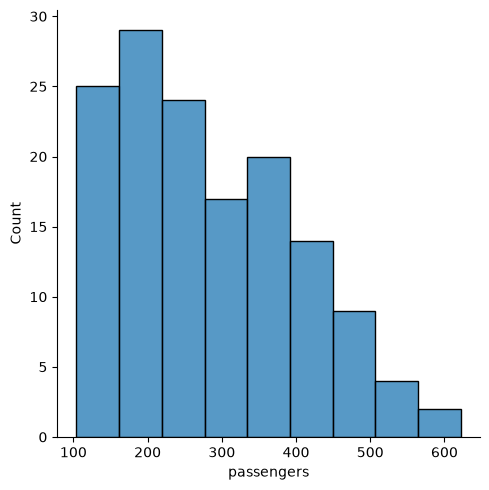

In [7]:
passenger = flight_df['passengers']
sns.displot(passenger)

In [8]:
crashed_df = sns.load_dataset('car_crashes')
crashed_df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


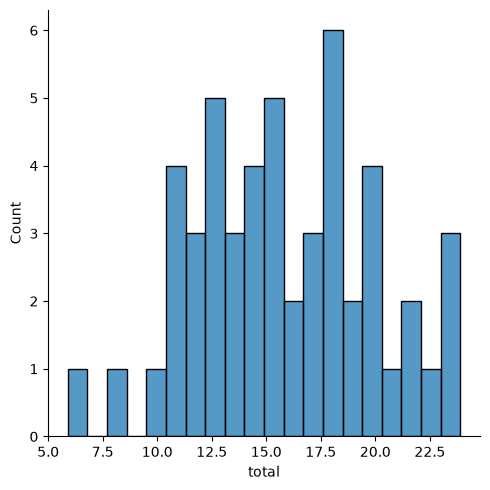

In [13]:
sns.displot(crashed_df['total'],bins = 20)

In [18]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

file_path = "annual_gold_rate.csv"
df = pd.read_csv(file_path)

print("=== ORIGINAL DATA SHAPE ===")
print(df.shape)

print("\n=== FIRST 5 ROWS ===")
print(df.head())

# 1. Remove duplicates
df_before = df.shape[0]
df = df.drop_duplicates()
df_after = df.shape[0]

print(f"\n=== DUPLICATES REMOVED ===")
print(f"Rows before: {df_before}, Rows after: {df_after}, Removed: {df_before - df_after}")

# 2. Identify numeric and categorical columns
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "category"]).columns.tolist()


print("\n=== NUMERIC FEATURES ===")
print(numeric_features)

print("\n=== CATEGORICAL FEATURES ===")
print(categorical_features)

# 3. Define transformers
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# 4. Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 5. FIT the preprocessor and transform data
X_processed = preprocessor.fit_transform(df)   # <-- this MUST run before accessing encoder

# 6. Get feature names from the fitted encoder
#    Now 'preprocessor' is fitted; 'encoder' inside it is also fitted.
cat_encoder = preprocessor.named_transformers_["cat"].named_steps["encoder"]

# If categorical_features is empty, this will fail; so guard against that:
if len(categorical_features) > 0:
    categorical_feature_names = cat_encoder.get_feature_names_out(categorical_features)
else:
    categorical_feature_names = np.array([])

numeric_feature_names = np.array(numeric_features)
all_feature_names = np.concatenate([numeric_feature_names, categorical_feature_names])

# 7. Convert processed data to DataFrame
df_processed = pd.DataFrame(
    X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed,
    columns=all_feature_names
)

print(df_processed.head())

=== ORIGINAL DATA SHAPE ===
(44, 7)

=== FIRST 5 ROWS ===
   Date     USD        EUR        GBP         INR         AED  CNY
0  1978  193.44  124.73580  100.65449         NaN         NaN  NaN
1  1979  304.68  185.06142  143.09014  2481.90512  1163.93597  NaN
2  1980  614.50  378.19461  263.80259  4831.74943  2278.36795  NaN
3  1981  459.26  360.90588  227.01948  3966.64790  1691.03194  NaN
4  1982  375.30  345.59742  215.53232  3553.62680  1378.72895  NaN

=== DUPLICATES REMOVED ===
Rows before: 44, Rows after: 44, Removed: 0

=== NUMERIC FEATURES ===
['Date', 'USD', 'EUR', 'GBP', 'INR', 'AED', 'CNY']

=== CATEGORICAL FEATURES ===
[]
       Date       USD       EUR       GBP       INR       AED  CNY
0 -1.693123 -1.037337 -1.143972 -0.988988  0.000000  0.000000  0.0
1 -1.614373 -0.805910 -0.989639 -0.869051 -0.861527 -0.815953  0.0
2 -1.535624 -0.161350 -0.495540 -0.527880 -0.797350 -0.176417  0.0
3 -1.456874 -0.484316 -0.539771 -0.631841 -0.820977 -0.513470  0.0
4 -1.378124 -0.658990 -

In [21]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

file_path = "annual_gold_rate.csv"
df = pd.read_csv(file_path)

print("=== ORIGINAL DATA SHAPE ===")
print(df.shape)

print("\n=== FIRST 5 ROWS ===")
print(df.head())

# 1. Remove duplicates
df_before = df.shape[0]
df = df.drop_duplicates()
df_after = df.shape[0]

print(f"\n=== DUPLICATES REMOVED ===")
print(f"Rows before: {df_before}, Rows after: {df_after}, Removed: {df_before - df_after}")
# 2. Identify numeric and categorical columns
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("\n=== NUMERIC FEATURES ===")
print(numeric_features)

print("\n=== CATEGORICAL FEATURES ===")
print(categorical_features)

# 3. Define transformers
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# 4. Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 5. FIT the preprocessor and transform data

print("\n=== APPLYING PREPROCESSING PIPELINE ===")
X_processed = preprocessor.fit_transform(df)

print("\n=== PROCESSED DATA SHAPE (NUMERIC + ENCODED CATEGORICAL) ===")
print(X_processed.shape)

# 6. Get feature names from the fitted encoder
#    Now 'preprocessor' is fitted; 'encoder' inside it is also fitted.
cat_encoder = preprocessor.named_transformers_["cat"].named_steps["encoder"]

# If categorical_features is empty, this will fail; so guard against that:
if len(categorical_features) > 0:
    categorical_feature_names = cat_encoder.get_feature_names_out(categorical_features)
else:
    categorical_feature_names = np.array([])

numeric_feature_names = np.array(numeric_features)
all_feature_names = np.concatenate([numeric_feature_names, categorical_feature_names])

# 7. Convert processed data to DataFrame
df_processed = pd.DataFrame(
    X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed,
    columns=all_feature_names
)

print(df_processed.head())

=== ORIGINAL DATA SHAPE ===
(44, 7)

=== FIRST 5 ROWS ===
   Date     USD        EUR        GBP         INR         AED  CNY
0  1978  193.44  124.73580  100.65449         NaN         NaN  NaN
1  1979  304.68  185.06142  143.09014  2481.90512  1163.93597  NaN
2  1980  614.50  378.19461  263.80259  4831.74943  2278.36795  NaN
3  1981  459.26  360.90588  227.01948  3966.64790  1691.03194  NaN
4  1982  375.30  345.59742  215.53232  3553.62680  1378.72895  NaN

=== DUPLICATES REMOVED ===
Rows before: 44, Rows after: 44, Removed: 0

=== NUMERIC FEATURES ===
['Date', 'USD', 'EUR', 'GBP', 'INR', 'AED', 'CNY']

=== CATEGORICAL FEATURES ===
[]

=== APPLYING PREPROCESSING PIPELINE ===

=== PROCESSED DATA SHAPE (NUMERIC + ENCODED CATEGORICAL) ===
(44, 7)
       Date       USD       EUR       GBP       INR       AED  CNY
0 -1.693123 -1.037337 -1.143972 -0.988988  0.000000  0.000000  0.0
1 -1.614373 -0.805910 -0.989639 -0.869051 -0.861527 -0.815953  0.0
2 -1.535624 -0.161350 -0.495540 -0.527880 -0.7